# Quantum Optics - Homework 1

## Jan Chelmecki

The task is to display the eigenfunctions of

$$
H = −E_J \cos (\phi - \phi_{ext}) + 4 E_C (n-n_{ext})^2 + \frac{E_L}{2} \phi^2
$$

where $\phi$ and $n$ are conjugate variables henceforth associated to position and momentum, respectively (it is really a matter of language, and I like the good old $x$ and $p$ better).

The strategy will be the following.
1. Define the operators in the position space, since this is how we will want to represent the wavefunctions.
2. Discretize the space with a fine 1D grid - operators will then be finite matrices, making the problem solvable.
3. For the potential, define a diagonal matrix.
4. Approximate the momentum operator $-i\hbar\partial_x$ with finite differences, and initialize the appropriate matrix.
5. Use the above to define the Hamiltionian and diagonalize it.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

### The potential

In [228]:
def solve(EJ,EC,EL,phi_ext,n_ext,xmax,N):

    ### discretize space
    x = np.linspace(-xmax,xmax, N)
    dx = x[1]-x[0]

    #define the momentum operators
    p2 = np.zeros((N,N), complex)
    s = -1/(dx)**2
    for i in range(N):
        if i>0:
            p2[i,i-1] = s
        #endif
        p2[i,i] = -2*s
        if i<N-1:
            p2[i,i+1] = s
        #endif
    #end
    T = 4*EC*p2

    ### define the potential
    V_vals = -EJ*np.cos(x-phi_ext) +EL/2 * x**2
    V = np.diag(V_vals)

    H = Qobj(T+V)
    energies, eigenstates = H.eigenstates()

    states=[]
    for n in range(4):
        psi = eigenstates[n].full().flatten()
        psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)  # normalize
        states.append(psi)
    return energies[:4:], states
#end

In [229]:
L = [1,2,3,4,5]

In [230]:
L[:4:]

[1, 2, 3, 4]

In [264]:
def show_states(EJ,EC,EL,phi_ext,n_ext,xmax,N):
    x = np.linspace(-xmax,xmax, N)
    V = -EJ*np.cos(x-phi_ext) +EL/2 * x**2

    energies, states = solve(EJ,EC,EL,phi_ext,n_ext,xmax,N)
    print("Energies = ", energies)
    plt.plot(x, V)
    for i in range(len(energies)):
        plt.plot(x,energies[i]+np.real(states[i]), label="|"+str(i)+">")
    plt.grid()
    plt.xlabel("$\phi$")
    plt.ylabel("E")
    xlim = np.abs(x[np.argmax(V)])
    plt.xlim(-xlim,xlim)
    plt.ylim(np.min(V)-0.2, V[int(N/2)]+1.0)
    plt.legend()
#end

Energies =  [-2.32642161 -2.32461348  1.38182271  1.43547638]


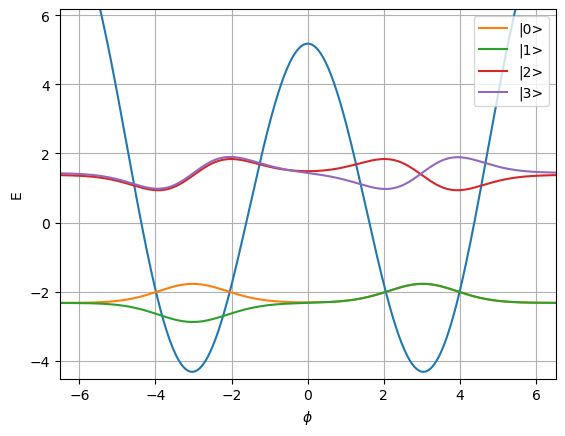

In [265]:
EJ = 5.178 #GHz*h
EC = 0.4144 #GHz*h
EL = 0.18 #GHz*h
phi_ext = np.pi*1.00
n_ext = 0.0

xmax = 10.0
N = 500

show_states(EJ,EC,EL,phi_ext,n_ext,xmax,N)

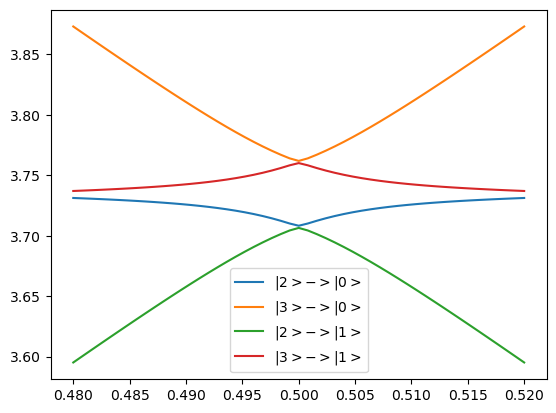

In [266]:
points = 51
phi_ext_list = np.linspace(0.96*np.pi,1.04*np.pi,points)
E_arr = np.zeros((4,points))

for i in range(points):
    EJ = 5.178 #GHz*h
    EC = 0.4144 #GHz*h
    EL = 0.18 #GHz*h
    phi_ext = phi_ext_list[i]
    E, states = solve(EJ,EC,EL,phi_ext,n_ext,xmax,N)
    E_arr[:,i] = E

plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[0,:],label="$|2>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[0,:],label="$|3>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[1,:],label="$|2>  ->  |1>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[1,:],label="$|3>  ->  |1>$")
plt.legend()

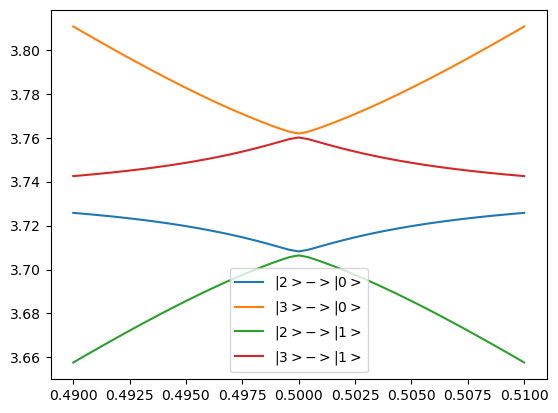

In [257]:
plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[0,:],label="$|2>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[0,:],label="$|3>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[1,:],label="$|2>  ->  |1>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[1,:],label="$|3>  ->  |1>$")
plt.legend()